# Predicción de Precios de Portátiles
Métrica de evaluación: **MAE** (error absoluto medio en euros)


## 1. Importar librerías y cargar datos

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [9]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
train.head()

Train: (912, 14)
Test:  (391, 13)


,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,697,705,Asus,Chromebook Flip,2 in 1 Convertible,12.5,Full HD / Touchscreen 1920x1080,Intel Core M M3-6Y30 0.9GHz,4GB,64GB Flash Storage,Intel HD Graphics 515,Chrome OS,1.2kg,669.0
1,435,442,Asus,Rog Strix,Gaming,17.3,Full HD 1920x1080,AMD Ryzen 1600 3.2GHz,8GB,256GB SSD + 1TB HDD,AMD Radeon RX 580,Windows 10,3.2kg,1695.0
2,735,743,Lenovo,V310-15IKB (i7-7500U/4GB/1TB/FHD/W10),Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,4GB,1TB HDD,Intel HD Graphics 620,Windows 10,1.85kg,779.0
3,864,875,Dell,XPS 13,Ultrabook,13.3,Quad HD+ / Touchscreen 3200x1800,Intel Core i7 7660U 2.5GHz,16GB,512GB SSD,Intel Iris Plus Graphics 640,Windows 10,1.29kg,2240.0
4,1176,1194,Lenovo,B51-80 (i7-6500U/4GB/1008GB/FHD/W7),Notebook,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,1.0TB Hybrid,Intel HD Graphics 520,Windows 7,2.32kg,825.0


## 2. Exploración rápida

In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                912 non-null    int64  
 1   laptop_ID         912 non-null    int64  
 2   Company           912 non-null    str    
 3   Product           912 non-null    str    
 4   TypeName          912 non-null    str    
 5   Inches            912 non-null    float64
 6   ScreenResolution  912 non-null    str    
 7   Cpu               912 non-null    str    
 8   Ram               912 non-null    str    
 9   Memory            912 non-null    str    
 10  Gpu               912 non-null    str    
 11  OpSys             912 non-null    str    
 12  Weight            912 non-null    str    
 13  Price_euros       912 non-null    float64
dtypes: float64(2), int64(2), str(10)
memory usage: 99.9 KB


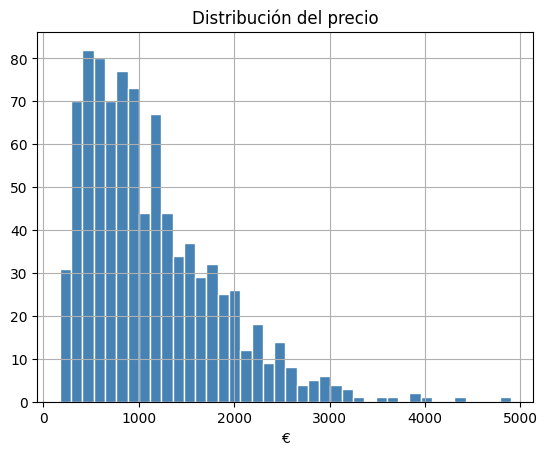

count     912.00
mean     1126.92
std       696.09
min       174.00
25%       589.00
50%       952.00
75%      1499.00
max      4899.00
Name: Price_euros, dtype: float64


In [11]:
# Distribución del precio (nuestra variable objetivo)
train['Price_euros'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución del precio')
plt.xlabel('€')
plt.show()

print(train['Price_euros'].describe().round(2))

## 3. Limpieza de datos



In [12]:
def limpiar(df):
    df = df.copy()

# --- RAM: '8GB' -> 8 ---
    df['Ram_GB'] = df['Ram'].str.replace('GB', '', regex=False).astype(int)

    # --- Weight: '1.5kg' -> 1.5 ---
    df['Weight_kg'] = df['Weight'].str.replace('kg', '', regex=False).astype(float)

    # extraemos marca, gama y velocidad
    df['Cpu_marca']    = df['Cpu'].apply(lambda x: x.split()[0])        # Intel / AMD
    df['Cpu_gama']     = df['Cpu'].apply(lambda x: x.split()[2] if len(x.split()) > 2 else 'Other')  # i3 / i5 / i7
    df['Cpu_GHz']      = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)

    # --- GPU: extraemos la marca ---
    df['Gpu_brand'] = df['Gpu'].apply(lambda x: x.split()[0])  # Intel / Nvidia / AMD

   # --- Pantalla táctil: si la descripción contiene 'Touchscreen' ---
    df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)

    # --- Storage: extraemos los GB ---
    df['Storage_GB'] = df['Memory'].str.extract(r'(\d+\.?\d*)').astype(float)
    es_tb = df['Memory'].str.contains('TB') & ~df['Memory'].str.contains('GB')
    df.loc[es_tb, 'Storage_GB'] = df.loc[es_tb, 'Storage_GB'] * 1000
    
    res = df['ScreenResolution'].str.extract(r'(\d{3,4})x(\d{3,4})')
    df['resolucion_pixeles'] = res[0].astype(float) * res[1].astype(float)

    return df

train = limpiar(train)
test  = limpiar(test)

train[['Ram_GB', 'Weight_kg', 'Touchscreen', 'Cpu_marca', 'Cpu_gama', 'Cpu_GHz', 'Gpu_brand', 'resolucion_pixeles']].head()

,Ram_GB,Weight_kg,Touchscreen,Cpu_marca,Cpu_gama,Cpu_GHz,Gpu_brand,resolucion_pixeles
0,4,1.20,1,Intel,M,0.9,Intel,2073600.0
1,8,3.20,0,AMD,1600,3.2,AMD,2073600.0
2,4,1.85,0,Intel,i7,2.7,Intel,2073600.0
3,16,1.29,1,Intel,i7,2.5,Intel,5760000.0
4,4,2.32,0,Intel,i7,2.5,Intel,2073600.0


## 4. Preparar features



Features usadas: ['Company', 'TypeName', 'OpSys', 'Cpu_marca', 'Cpu_gama', 'Gpu_brand', 'Inches', 'Ram_GB', 'Weight_kg', 'Touchscreen', 'Cpu_GHz', 'Storage_GB', 'resolucion_pixeles']
Filas de train: 912 | Filas de test: 391


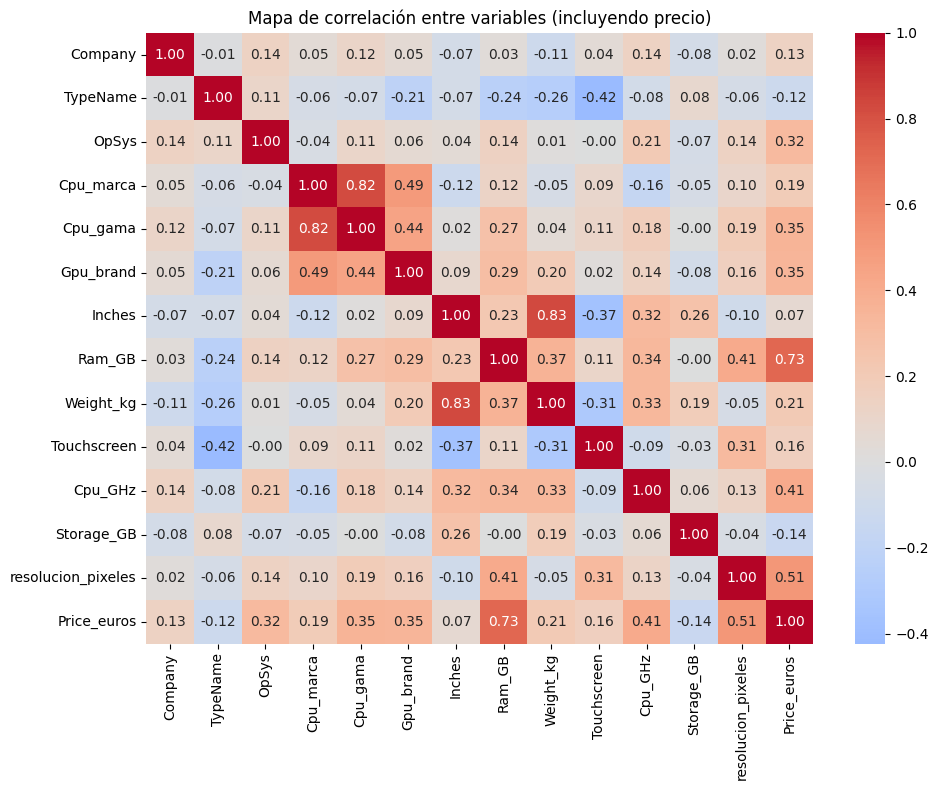

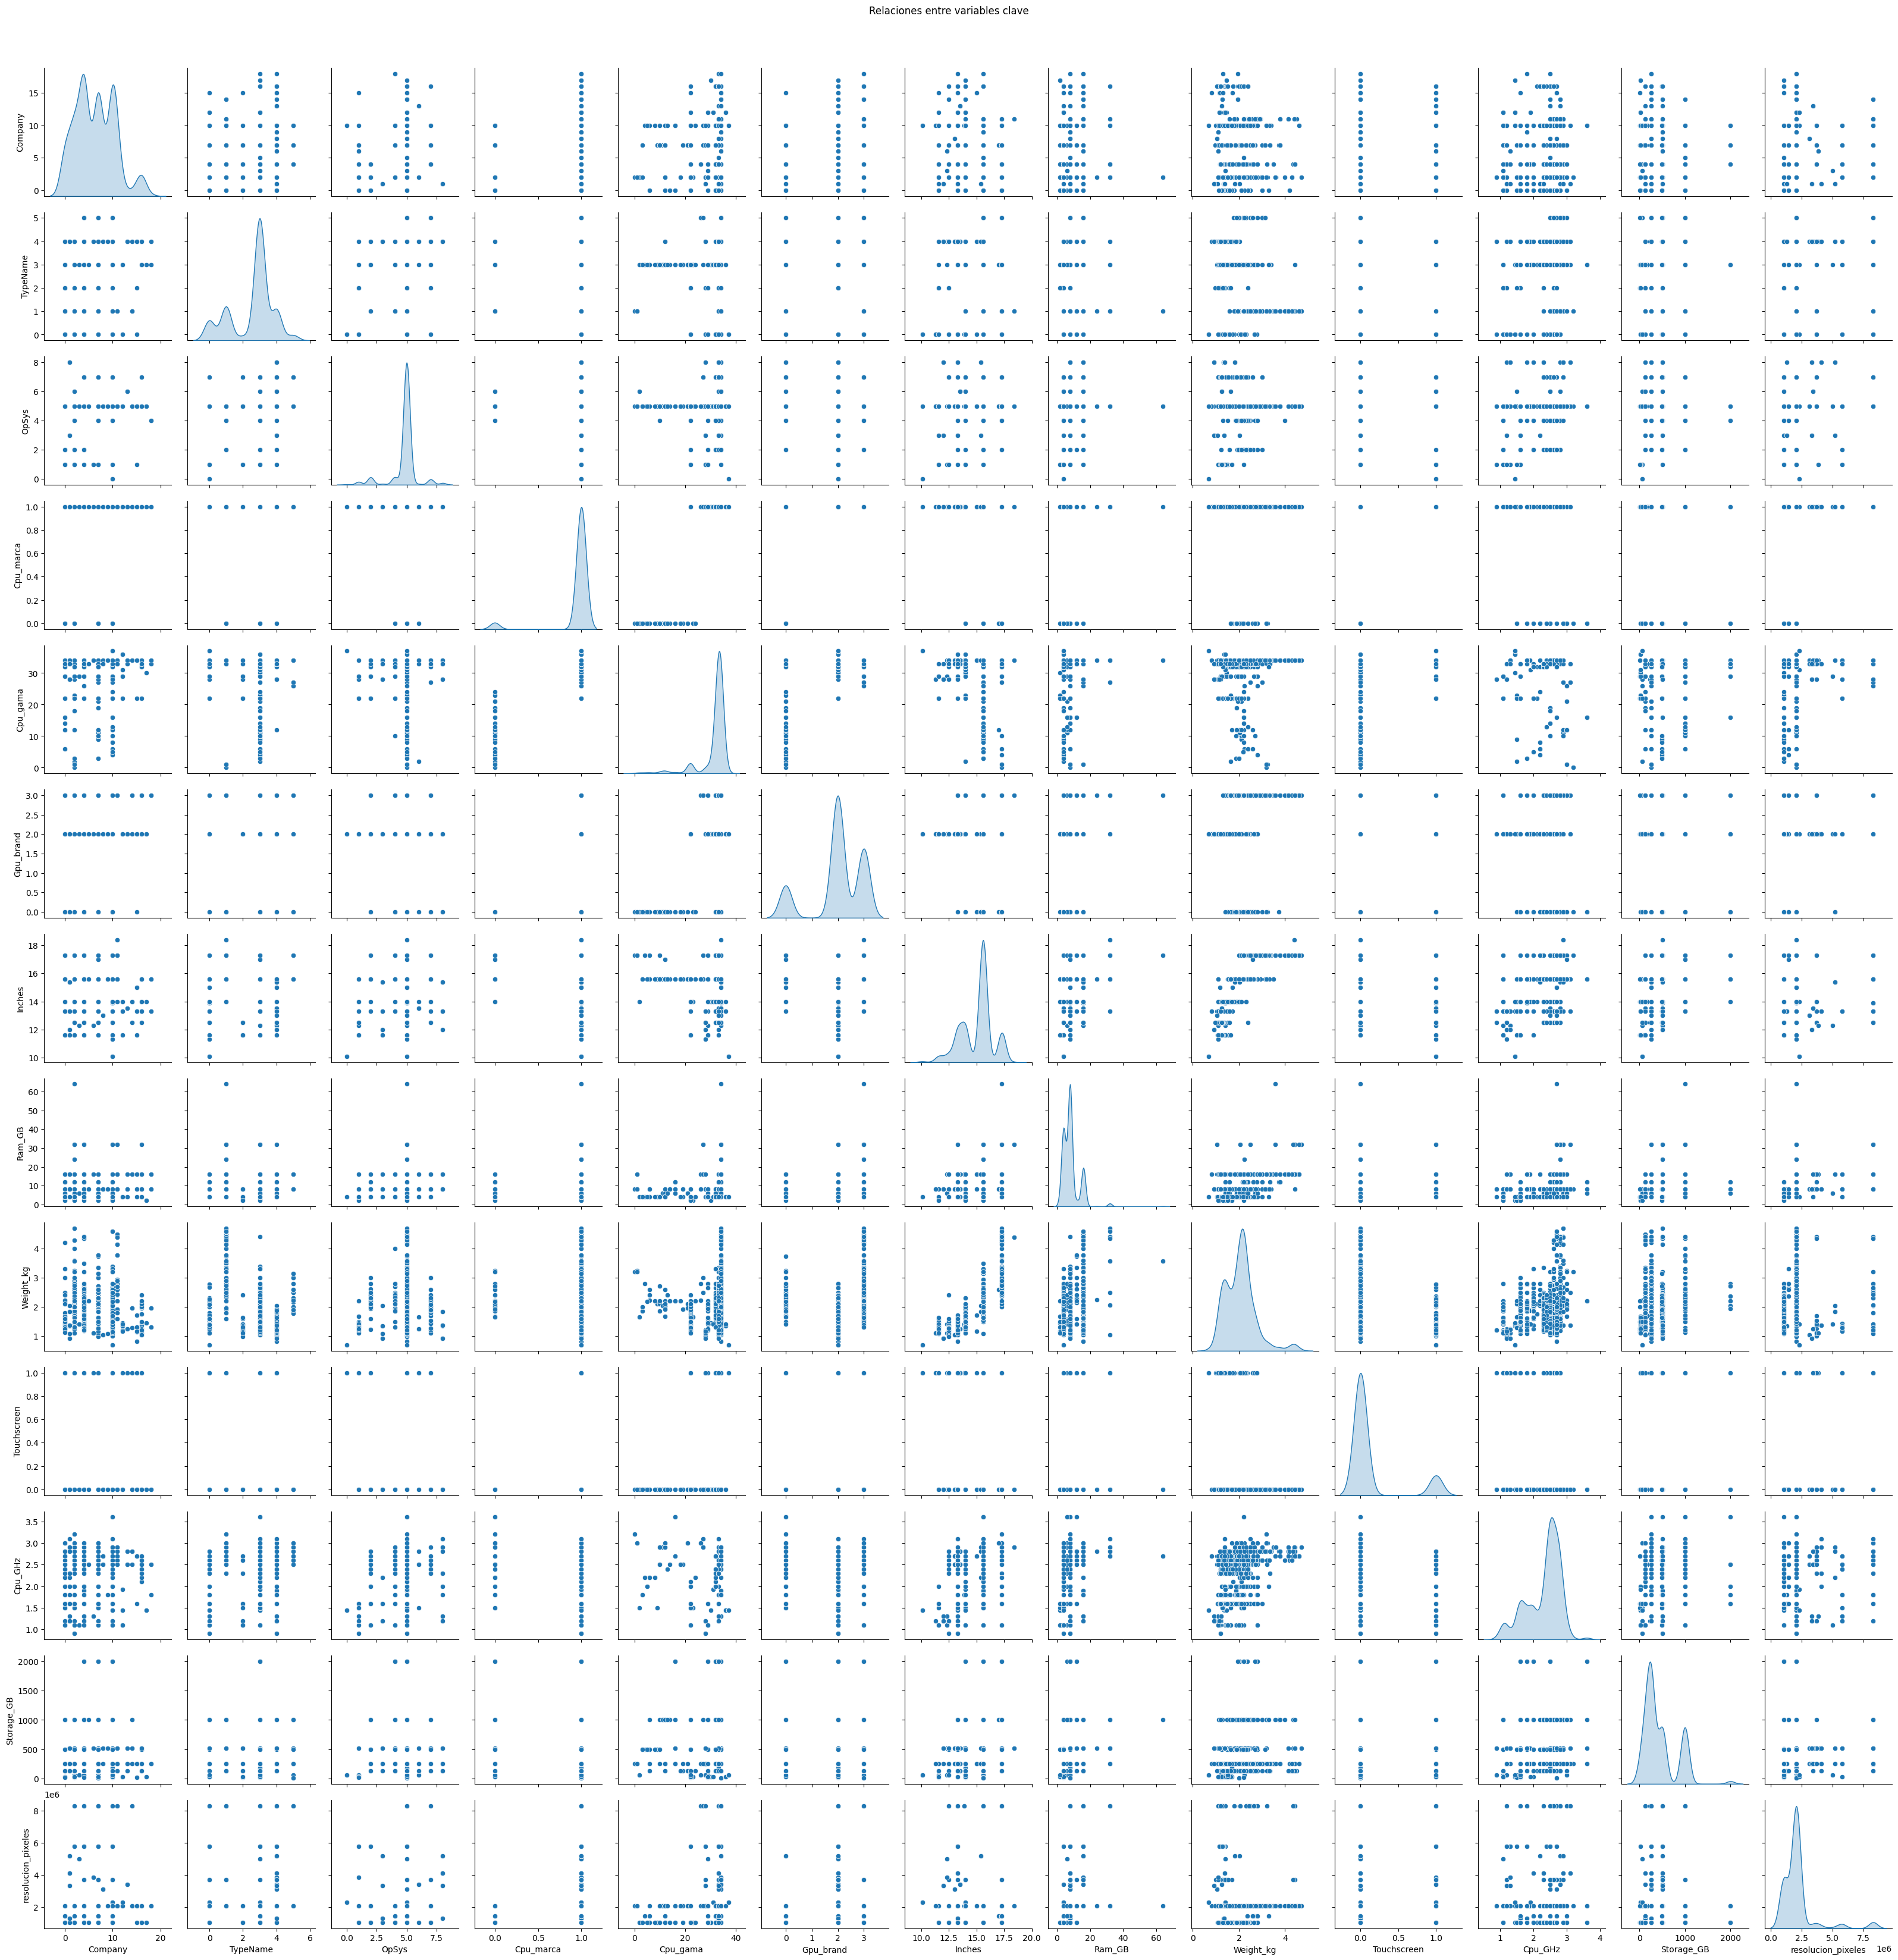

In [19]:
# Columnas que usamos como features
features_cat = ['Company', 'TypeName', 'OpSys','Cpu_marca', 'Cpu_gama', 'Gpu_brand']   # texto → número
features_num = ['Inches', 'Ram_GB', 'Weight_kg', 'Touchscreen', 'Cpu_GHz', 'Storage_GB', 'resolucion_pixeles']  # ya son números

# Codificamos las categóricas
for col in features_cat:
    le = LabelEncoder()
    # Entrenamos el encoder con los valores de train Y test juntos
    # para que no haya categorías desconocidas
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

all_features = features_cat + features_num

X      = train[all_features]
y      = train['Price_euros']
X_test = test[all_features]

print(f"Features usadas: {all_features}")
print(f"Filas de train: {X.shape[0]} | Filas de test: {X_test.shape[0]}")

# --- Heatmap de correlación ---
plt.figure(figsize=(10, 8))
corr = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Mapa de correlación entre variables (incluyendo precio)')
plt.tight_layout()
plt.show()

# --- Pairplot: relaciones entre variables clave ---
sns.pairplot(train[all_features], diag_kind='kde')
plt.suptitle('Relaciones entre variables clave', y=1.02)
plt.show()

## 5. Entrenamiento y evaluación

Dividimos el train en **80% para entrenar** y **20% para validar** (comprobar el error antes de enviarlo).

Probamos dos modelos:
- **Árbol de Decisión**: sencillo, aprende reglas simples
- **Random Forest**: muchos árboles juntos, suele funcionar mejor


In [14]:
# Partición 80/20
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Árbol de Decisión ---
arbol = DecisionTreeRegressor(max_depth=6, random_state=42)
arbol.fit(X_train, y_train)
mae_arbol = mean_absolute_error(y_val, arbol.predict(X_val))

# --- Random Forest ---
bosque = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
bosque.fit(X_train, y_train)
mae_bosque = mean_absolute_error(y_val, bosque.predict(X_val))

print(f"MAE Árbol de Decisión : {mae_arbol:.1f} €")
print(f"MAE Random Forest     : {mae_bosque:.1f} €")
print(f"\n→ El mejor modelo es el que tenga menor MAE")
print(f" r2_train_arbol = arbol.score(X_train, y_train): {arbol.score(X_train, y_train):.3f}")
print(f" r2_val_arbol   = arborbol.score(X_val, y_val): {arbol.score(X_val, y_val):.3f}")
print(f" r2_train_bosque = bosque.score(X_train, y_train): {bosque.score(X_train, y_train):.3f}")
print(f" r2_val_bosque   = bosque.score(X_val, y_val): {bosque.score(X_val, y_val):.3f}")

MAE Árbol de Decisión : 281.1 €
MAE Random Forest     : 214.0 €

→ El mejor modelo es el que tenga menor MAE
 r2_train_arbol = arbol.score(X_train, y_train): 0.853
 r2_val_arbol   = arborbol.score(X_val, y_val): 0.631
 r2_train_bosque = bosque.score(X_train, y_train): 0.940
 r2_val_bosque   = bosque.score(X_val, y_val): 0.768


In [24]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
mae_xgb = mean_absolute_error(y_val, xgb.predict(X_val))
print(f"MAE XGBoost: {mae_xgb:.1f} €")
print(f"R2_train XGBoost: {xgb.score(X_train, y_train):.3f}") 
print(f"R2_val XGBoost: {xgb.score(X_val, y_val):.3f}")


MAE XGBoost: 180.8 €
R2_train XGBoost: 0.968
R2_val XGBoost: 0.836


In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
mae_gb = mean_absolute_error(y_val, gb.predict(X_val))
print(f"MAE Gradient Boosting: {mae_gb:.1f} €")
print(f"R2_train Gradient Boosting: {gb.score(X_train, y_train):.3f}")
print(f"R2_val Gradient Boosting: {gb.score(X_val, y_val):.3f}")

MAE Gradient Boosting: 192.2 €
R2_train Gradient Boosting: 0.937
R2_val Gradient Boosting: 0.812


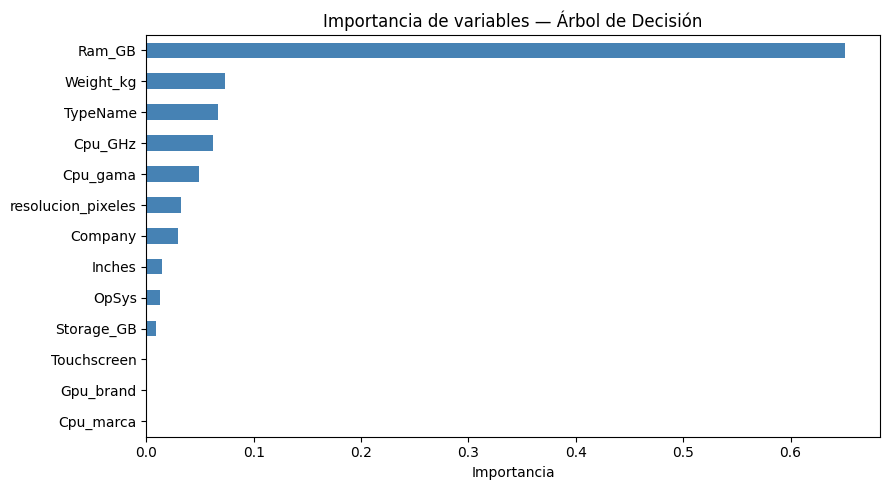

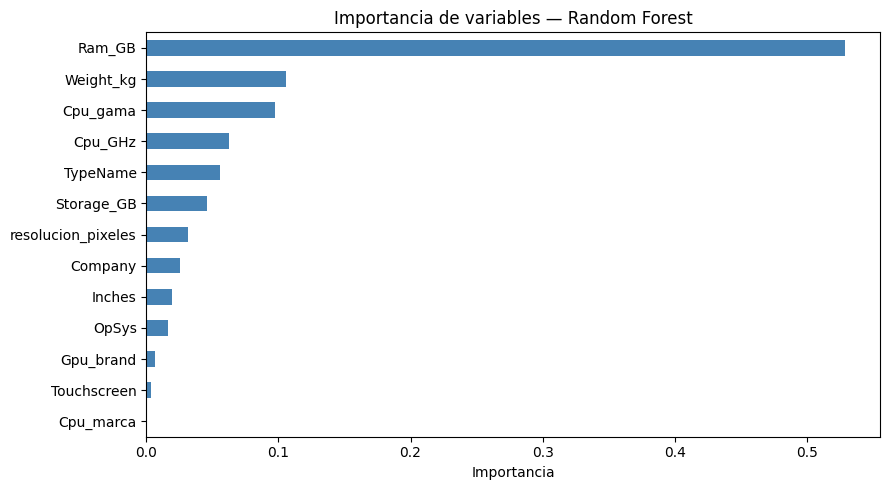

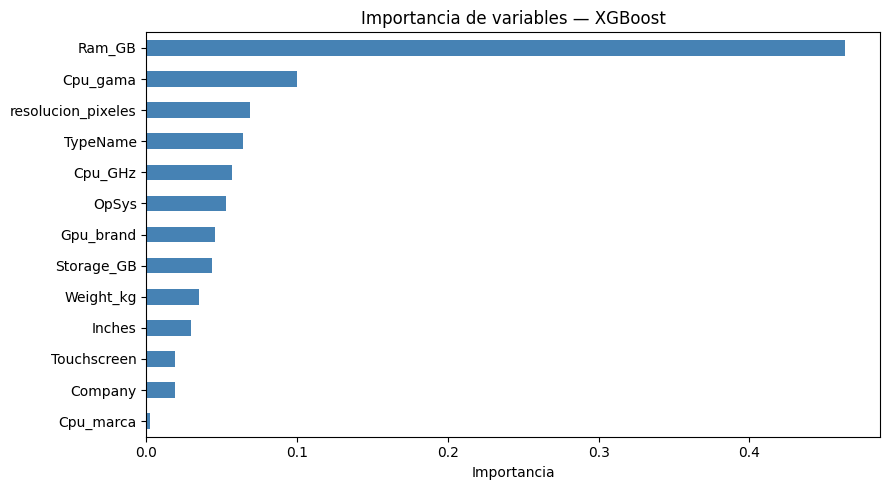

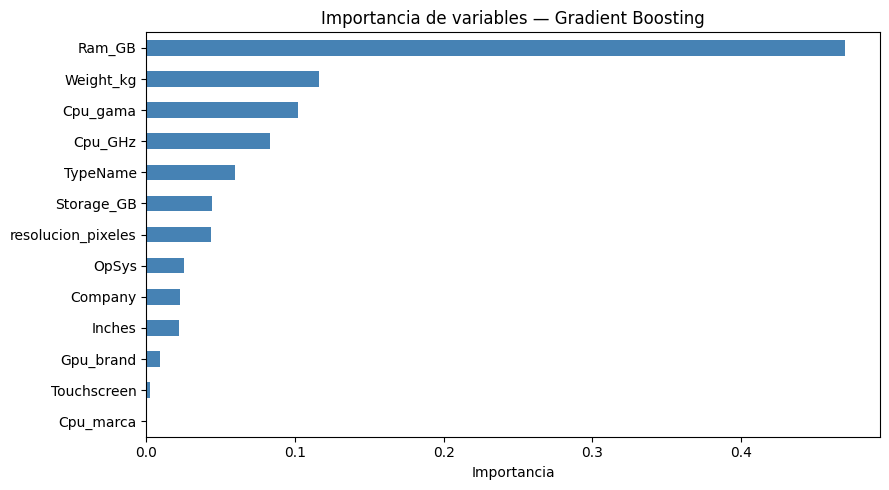

In [21]:
# Creamos un diccionario con todos los modelos que ya has entrenado
modelos = {
    'Árbol de Decisión': arbol,
    'Random Forest': bosque,
    'XGBoost': xgb,
    'Gradient Boosting': gb
}

# Iteramos sobre el diccionario para graficar las features de cada uno
for nombre, modelo in modelos.items():
    # Comprobamos que el modelo tenga el atributo de importancia de variables
    if hasattr(modelo, 'feature_importances_'):
        imp = pd.Series(modelo.feature_importances_, index=all_features)
        # Ordenamos los valores para que el gráfico se vea de menor a mayor importancia
        imp = imp.sort_values(ascending=True)

        plt.figure(figsize=(9, 5))
        imp.plot(kind='barh', color='steelblue')
        plt.title(f'Importancia de variables — {nombre}')
        plt.xlabel('Importancia')
        plt.tight_layout()
        plt.show()

## 6. Predicción y submission

Usamos el mejor modelo para predecir los precios del test y guardamos el archivo para subir a Kaggle.


In [14]:
# Reentrenamos con TODO el train (no solo el 80%) para usar más datos
xgb.fit(X, y)

predicciones = xgb.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'Price_euros': predicciones.round(2)
})

submission.to_csv('submission.csv', index=False)
print("submission.csv guardado ✅")
submission.head(10)

submission.csv guardado ✅


,id,Price_euros
0,824,1854.050049
1,101,380.140015
2,1157,2027.939941
3,940,1396.599976
4,853,1601.520020
5,650,2456.510010
6,317,224.500000
7,217,974.080017
8,489,1639.810059
9,1245,1665.540039
